# Lighthouse: Fundraising Campaign Effectiveness Analysis

**Business Problem:** The organization runs fundraising campaigns but isn't sure which ones actually move the needle—generating real donations versus just noise. This notebook applies multiple machine learning and statistical methods to answer:

> *Which campaigns meaningfully drive donation value AND donor participation, and which factors explain campaign performance?*

**Outcome Metric (Composite):** We evaluate campaigns on two dimensions:
- **Total Estimated Value** raised (all donation types converted to `estimated_value`)
- **Unique Donor Count** (number of supporters participating)

**Methods Compared (from textbook):**
1. Descriptive statistics + visualization (baseline)
2. Multiple Linear Regression — MLR (Ch. 9)
3. Decision Tree Regression (Ch. 12)
4. Cross-validated model comparison (Ch. 15)
5. Summary: Which campaign(s) moved the needle and why

## 0. Setup & Data Loading

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [47]:
# ── Load core tables ────────────────────────────────────────────────
# Update BASE_PATH to wherever the CSV files are stored
BASE_PATH = 'lighthouse_csv_v7/'

donations = pd.read_csv('donations.csv', parse_dates=['donation_date'])
supporters = pd.read_csv('supporters.csv')

print(f'donations: {donations.shape}')
print(f'supporters: {supporters.shape}')
donations.head(3)

donations: (420, 13)
supporters: (60, 15)


,donation_id,supporter_id,donation_type,donation_date,is_recurring,campaign_name,channel_source,currency_code,amount,estimated_value,impact_unit,notes,referral_post_id
0,1,42,Monetary,2025-12-31,False,NaN,Campaign,PHP,717.18,717.18,pesos,In support of safehouse operations,NaN
1,2,25,Time,2025-12-02,True,Year-End Hope,Event,NaN,NaN,35.15,hours,Community outreach support,NaN
2,3,19,Monetary,2024-12-02,False,NaN,PartnerReferral,PHP,1074.65,1074.65,pesos,Campaign support,NaN


## 1. Data Preparation

We use `estimated_value` as the universal value metric so that monetary, in-kind, time, and skills donations are all comparable. Donations without a campaign name are tagged as `'No Campaign'` for contrast.

In [48]:
# ── Fill NaN campaign names ──────────────────────────────────────────
donations['campaign'] = donations['campaign_name'].fillna('No Campaign')

# ── Add time features ────────────────────────────────────────────────
donations['year']  = donations['donation_date'].dt.year
donations['month'] = donations['donation_date'].dt.month
donations['dow']   = donations['donation_date'].dt.dayofweek   # 0=Mon

# ── Merge supporter info ─────────────────────────────────────────────
df = donations.merge(supporters[['supporter_id','supporter_type',
                                  'acquisition_channel','region']],
                     on='supporter_id', how='left')

# ── Quick sanity check ───────────────────────────────────────────────
print('Donation types:', df['donation_type'].value_counts().to_dict())
print('\nCampaigns:')
print(df['campaign'].value_counts())
print('\nNull estimated_value:', df['estimated_value'].isna().sum())

Donation types: {'Monetary': 234, 'InKind': 98, 'Time': 46, 'SocialMedia': 23, 'Skills': 19}

Campaigns:
campaign
No Campaign         275
Year-End Hope        60
Summer of Safety     35
Back to School       32
GivingTuesday        18
Name: count, dtype: int64

Null estimated_value: 0


In [49]:
# estimated_value is our label — drop rows where it is missing
df_model = df.dropna(subset=['estimated_value']).copy()
print(f'Rows kept for modeling: {len(df_model)} / {len(df)}')

Rows kept for modeling: 420 / 420


## 2. Descriptive Analysis — Baseline Campaign Comparison

Before any modeling, we look at raw numbers. This gives us the *what* before we explain the *why*.

In [50]:
# ── Campaign-level summary ───────────────────────────────────────────
campaign_summary = (
    df_model
    .groupby('campaign')
    .agg(
        total_value   = ('estimated_value', 'sum'),
        mean_value    = ('estimated_value', 'mean'),
        donor_count   = ('supporter_id',    'nunique'),
        donation_count= ('donation_id',     'count'),
    )
    .reset_index()
    .sort_values('total_value', ascending=False)
)

# Composite score: normalize each metric 0-1 then average
for col in ['total_value','donor_count']:
    mn, mx = campaign_summary[col].min(), campaign_summary[col].max()
    campaign_summary[f'{col}_norm'] = (campaign_summary[col] - mn) / (mx - mn + 1e-9)

campaign_summary['composite_score'] = (
    campaign_summary['total_value_norm'] * 0.5 +
    campaign_summary['donor_count_norm'] * 0.5
).round(3)

display_cols = ['campaign','total_value','mean_value','donor_count',
                'donation_count','composite_score']
print(campaign_summary[display_cols].to_string(index=False))

        campaign  total_value  mean_value  donor_count  donation_count  composite_score
     No Campaign    188837.94  686.683418           57             275            1.000
   Year-End Hope     45473.46  757.891000           34              60            0.311
  Back to School     24178.27  755.570938           27              32            0.165
Summer of Safety     21962.46  627.498857           22              35            0.098
   GivingTuesday     13255.68  736.426667           16              18            0.000


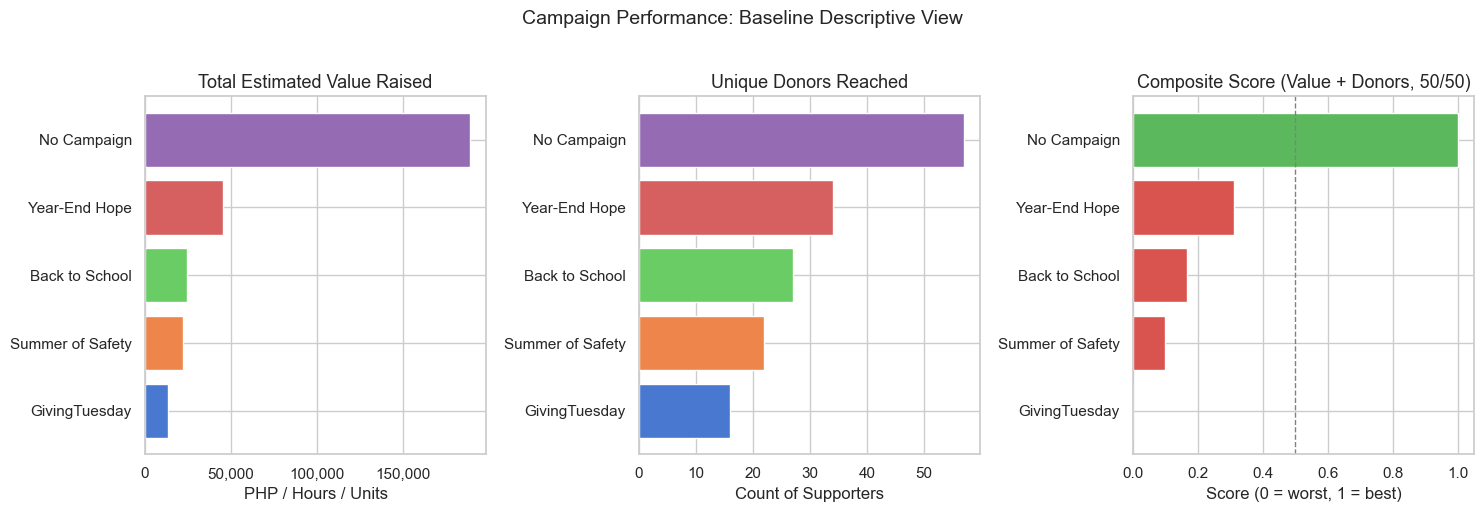

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cs = campaign_summary.sort_values('total_value', ascending=True)

# Total value
axes[0].barh(cs['campaign'], cs['total_value'], color=sns.color_palette('muted'))
axes[0].set_title('Total Estimated Value Raised')
axes[0].set_xlabel('PHP / Hours / Units')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Donor count
axes[1].barh(cs['campaign'], cs['donor_count'], color=sns.color_palette('muted', 5))
axes[1].set_title('Unique Donors Reached')
axes[1].set_xlabel('Count of Supporters')

# Composite score
cs2 = campaign_summary.sort_values('composite_score', ascending=True)
colors = ['#d9534f' if s < 0.4 else '#5cb85c' if s > 0.7 else '#f0ad4e'
          for s in cs2['composite_score']]
axes[2].barh(cs2['campaign'], cs2['composite_score'], color=colors)
axes[2].set_title('Composite Score (Value + Donors, 50/50)')
axes[2].set_xlabel('Score (0 = worst, 1 = best)')
axes[2].axvline(0.5, color='gray', linestyle='--', linewidth=1)

plt.suptitle('Campaign Performance: Baseline Descriptive View', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

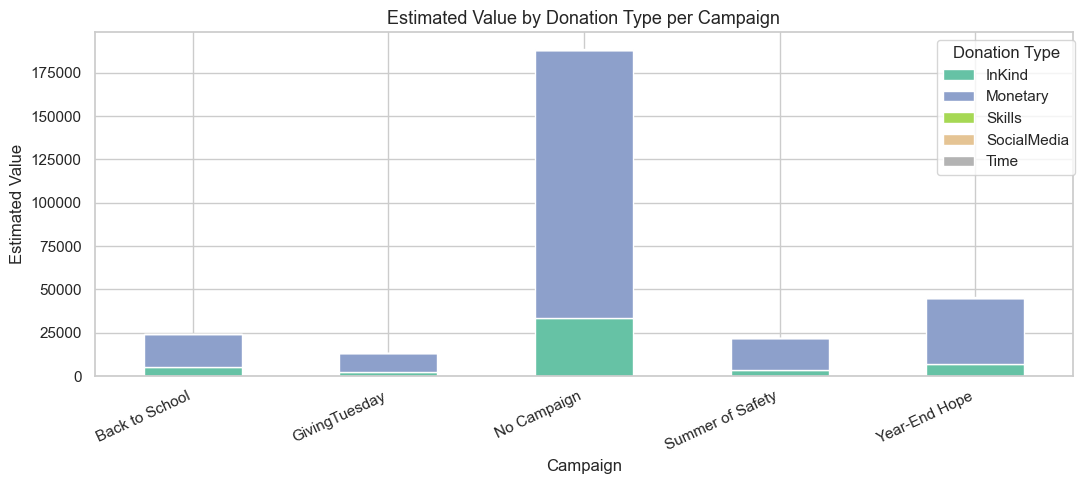

In [52]:
# ── Donation type breakdown per campaign ─────────────────────────────
type_breakdown = (
    df_model
    .groupby(['campaign', 'donation_type'])['estimated_value']
    .sum()
    .unstack(fill_value=0)
)

type_breakdown.plot(kind='bar', stacked=True, figsize=(11, 5),
                    colormap='Set2', edgecolor='white')
plt.title('Estimated Value by Donation Type per Campaign')
plt.xlabel('Campaign')
plt.ylabel('Estimated Value')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Donation Type', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

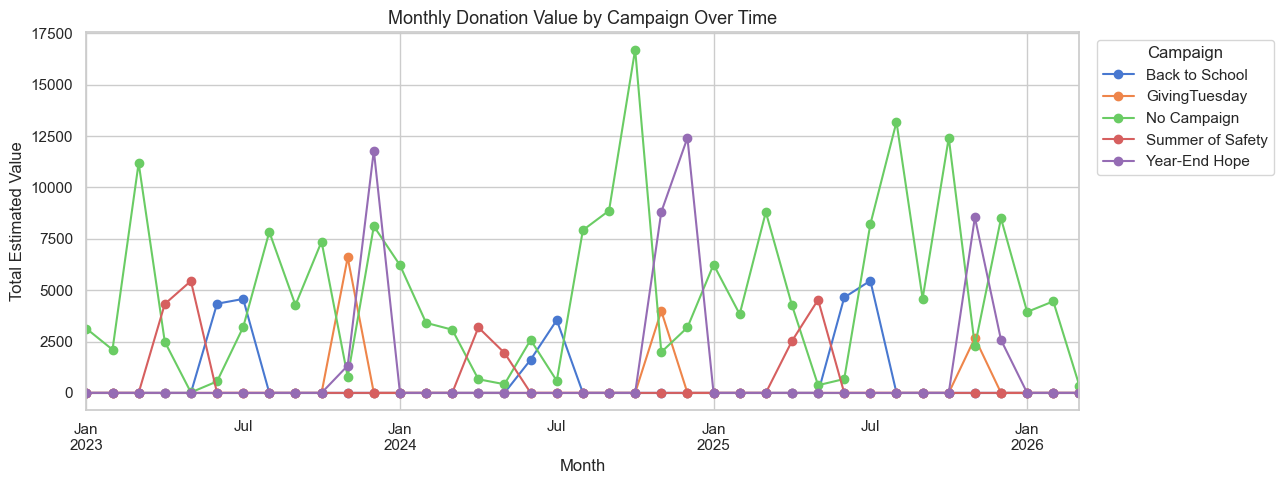

In [53]:
# ── Donations over time, colored by campaign ─────────────────────────
df_time = df_model.copy()
df_time['month_year'] = df_time['donation_date'].dt.to_period('M').dt.to_timestamp()

pivot_time = (
    df_time.groupby(['month_year', 'campaign'])['estimated_value']
    .sum()
    .unstack(fill_value=0)
)

pivot_time.plot(figsize=(13, 5), marker='o', linewidth=1.5)
plt.title('Monthly Donation Value by Campaign Over Time')
plt.xlabel('Month')
plt.ylabel('Total Estimated Value')
plt.legend(title='Campaign', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

## 3. Method 1 — Multiple Linear Regression (MLR)

**From textbook Ch. 9:** MLR estimates the independent effect of each feature (including campaign dummies) on donation value while holding other variables constant. This answers: *After controlling for channel, donor type, and timing — which campaigns are associated with significantly higher donation values?*

**Interpretation:** A campaign coefficient that is positive and statistically significant (p < 0.05) means that campaign independently drives higher donation values compared to the reference group (`No Campaign`).

In [54]:
# ── Feature engineering for MLR ──────────────────────────────────────
mlr_df = df_model.copy()

# Dummy-encode categoricals (drop_first=True to avoid multicollinearity)
cat_cols = ['campaign', 'channel_source', 'donation_type', 'acquisition_channel']
mlr_dummies = pd.get_dummies(mlr_df[cat_cols], drop_first=True, dtype=int)

# Numeric features
mlr_numeric = mlr_df[['month', 'year', 'is_recurring']].copy()
mlr_numeric['is_recurring'] = mlr_numeric['is_recurring'].astype(int)

X_mlr = pd.concat([mlr_numeric, mlr_dummies], axis=1).assign(const=1)
y_mlr = mlr_df['estimated_value']

print(f'Feature matrix shape: {X_mlr.shape}')
print('Campaign dummy columns:', [c for c in X_mlr.columns if 'campaign' in c])

Feature matrix shape: (420, 21)
Campaign dummy columns: ['campaign_GivingTuesday', 'campaign_No Campaign', 'campaign_Summer of Safety', 'campaign_Year-End Hope']


In [55]:
# ── Fit MLR using statsmodels (Ch. 9 approach) ───────────────────────
model_mlr = sm.OLS(y_mlr, X_mlr)
results_mlr = model_mlr.fit()

print(results_mlr.summary())

                            OLS Regression Results                            
Dep. Variable:        estimated_value   R-squared:                       0.387
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     12.60
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           1.37e-31
Time:                        15:34:29   Log-Likelihood:                -3252.0
No. Observations:                 420   AIC:                             6546.
Df Residuals:                     399   BIC:                             6631.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
mo

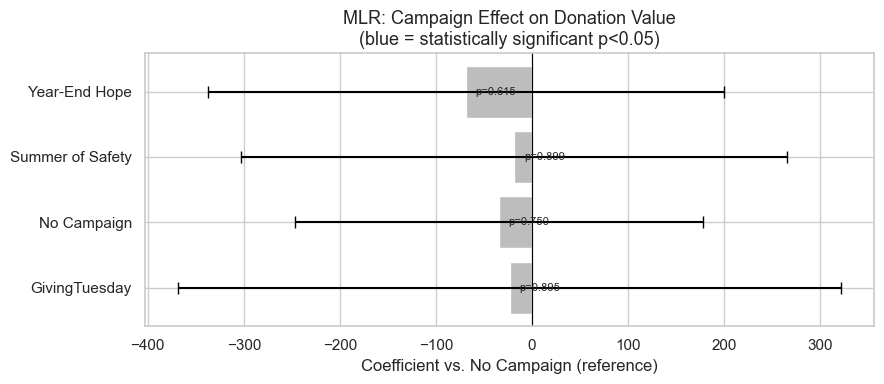


MLR R² = 0.387
MLR Adj. R² = 0.356


In [56]:
# ── Extract and plot campaign-specific coefficients ───────────────────
campaign_coefs = (
    results_mlr.summary2().tables[1]
    .reset_index()
    .rename(columns={'index': 'feature', 'Coef.': 'coef',
                     'P>|t|': 'pval', '[0.025': 'ci_low', '0.975]': 'ci_high'})
    .query('feature.str.startswith("campaign")')
    .copy()
)

campaign_coefs['significant'] = campaign_coefs['pval'] < 0.05
campaign_coefs['label'] = campaign_coefs['feature'].str.replace('campaign_', '', regex=False)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2196F3' if sig else '#BDBDBD' for sig in campaign_coefs['significant']]
bars = ax.barh(campaign_coefs['label'], campaign_coefs['coef'], color=colors)

# Error bars (95% CI)
ax.errorbar(
    campaign_coefs['coef'], campaign_coefs['label'],
    xerr=[
        campaign_coefs['coef'] - campaign_coefs['ci_low'],
        campaign_coefs['ci_high'] - campaign_coefs['coef']
    ],
    fmt='none', color='black', capsize=4
)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient vs. No Campaign (reference)')
ax.set_title('MLR: Campaign Effect on Donation Value\n(blue = statistically significant p<0.05)')

# p-value annotations
for _, row in campaign_coefs.iterrows():
    ax.text(row['coef'] + 10, row['label'], f"p={row['pval']:.3f}",
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f'\nMLR R² = {results_mlr.rsquared:.3f}')
print(f'MLR Adj. R² = {results_mlr.rsquared_adj:.3f}')

## 4. Method 2 — Decision Tree Regression

**From textbook Ch. 12:** Decision trees capture nonlinear patterns and interactions between features without requiring linearity assumptions. After fitting the tree, **feature importance** tells us which variables (including campaign) have the greatest influence on donation value.

Decision trees complement MLR: where MLR gives us interpretable coefficients, the tree reveals the structure of the data and highlights where campaign effects cluster.

In [57]:
# ── Prepare features for tree (same dummies, no const needed) ────────
X_tree = X_mlr.drop(columns=['const'])
y_tree = y_mlr

print(f'Tree feature matrix: {X_tree.shape}')

Tree feature matrix: (420, 20)


In [58]:
# ── Fit decision tree with mild regularization to prevent overfitting ─
tree_model = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)
tree_model.fit(X_tree, y_tree)

y_pred_tree = tree_model.predict(X_tree)
r2_tree  = r2_score(y_tree, y_pred_tree)
mae_tree = mean_absolute_error(y_tree, y_pred_tree)

print(f'Decision Tree (in-sample)  R² = {r2_tree:.3f} | MAE = {mae_tree:.2f}')
print('\nNote: In-sample metrics are optimistic (Ch. 9 caution). Cross-validation follows in Section 5.')

Decision Tree (in-sample)  R² = 0.464 | MAE = 320.19

Note: In-sample metrics are optimistic (Ch. 9 caution). Cross-validation follows in Section 5.


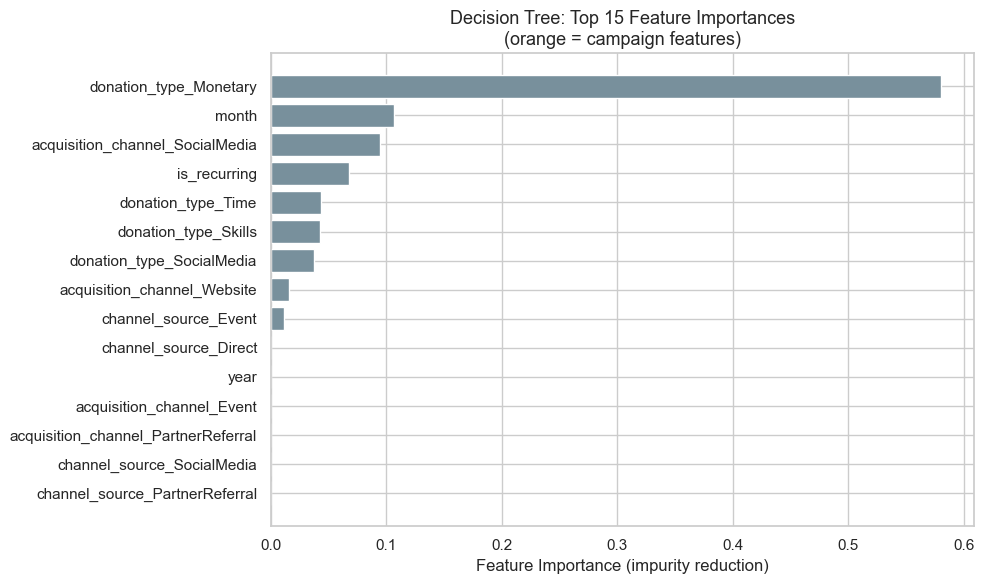

In [59]:
# ── Feature importance plot ────────────────────────────────────────────
importance_df = (
    pd.DataFrame({'feature': X_tree.columns,
                  'importance': tree_model.feature_importances_})
    .sort_values('importance', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = ['#FF7043' if 'campaign' in f else '#78909C'
              for f in importance_df['feature']]
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
        color=colors_imp[::-1])
ax.set_xlabel('Feature Importance (impurity reduction)')
ax.set_title('Decision Tree: Top 15 Feature Importances\n(orange = campaign features)')
plt.tight_layout()
plt.show()

In [60]:
# ── Print simplified decision rules ───────────────────────────────────
rules = export_text(tree_model, feature_names=list(X_tree.columns), max_depth=3)
print('Decision Tree Rules (top 3 levels):')
print(rules)

Decision Tree Rules (top 3 levels):
|--- donation_type_Monetary <= 0.50
|   |--- donation_type_Time <= 0.50
|   |   |--- donation_type_SocialMedia <= 0.50
|   |   |   |--- donation_type_Skills <= 0.50
|   |   |   |   |--- value: [527.74]
|   |   |   |--- donation_type_Skills >  0.50
|   |   |   |   |--- value: [12.28]
|   |   |--- donation_type_SocialMedia >  0.50
|   |   |   |--- acquisition_channel_Event <= 0.50
|   |   |   |   |--- value: [7.64]
|   |   |   |--- acquisition_channel_Event >  0.50
|   |   |   |   |--- value: [4.04]
|   |--- donation_type_Time >  0.50
|   |   |--- acquisition_channel_SocialMedia <= 0.50
|   |   |   |--- channel_source_Direct <= 0.50
|   |   |   |   |--- value: [22.58]
|   |   |   |--- channel_source_Direct >  0.50
|   |   |   |   |--- value: [15.83]
|   |   |--- acquisition_channel_SocialMedia >  0.50
|   |   |   |--- year <= 2024.00
|   |   |   |   |--- value: [16.88]
|   |   |   |--- year >  2024.00
|   |   |   |   |--- value: [9.52]
|--- donation_ty

## 5. Method 3 — Cross-Validated Model Comparison (Ch. 15)

**From textbook Ch. 15:** In-sample R² and MAE are optimistic because the model has already "seen" the training data. K-Fold cross-validation gives a more honest estimate of how well each model generalizes.

We compare:
- **MLR** — linear, interpretable
- **Decision Tree (depth=4)** — nonlinear, captures interactions
- **Decision Tree (depth=2)** — simpler, more robust with small N

In [61]:
from sklearn.linear_model import LinearRegression

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'MLR (scikit-learn)':      LinearRegression(),
    'Decision Tree (depth=4)': DecisionTreeRegressor(max_depth=4, min_samples_leaf=5, random_state=42),
    'Decision Tree (depth=2)': DecisionTreeRegressor(max_depth=2, min_samples_leaf=5, random_state=42),
}

cv_results = {}
for name, m in models.items():
    scores = cross_val_score(m, X_tree, y_tree, cv=kf,
                             scoring='neg_mean_absolute_error')
    r2s    = cross_val_score(m, X_tree, y_tree, cv=kf, scoring='r2')
    cv_results[name] = {
        'CV MAE (mean)':  -scores.mean(),
        'CV MAE (std)':    scores.std(),
        'CV R² (mean)':    r2s.mean(),
        'CV R² (std)':     r2s.std(),
    }

cv_df = pd.DataFrame(cv_results).T.round(3)
print('=== 5-Fold Cross-Validation Results ===')
print(cv_df.to_string())
print('\nLower CV MAE = better generalization | Higher CV R² = more variance explained')

=== 5-Fold Cross-Validation Results ===
                         CV MAE (mean)  CV MAE (std)  CV R² (mean)  CV R² (std)
MLR (scikit-learn)             389.261        58.200         0.346        0.068
Decision Tree (depth=4)        352.989        60.414         0.310        0.062
Decision Tree (depth=2)        388.302        62.368         0.308        0.050

Lower CV MAE = better generalization | Higher CV R² = more variance explained


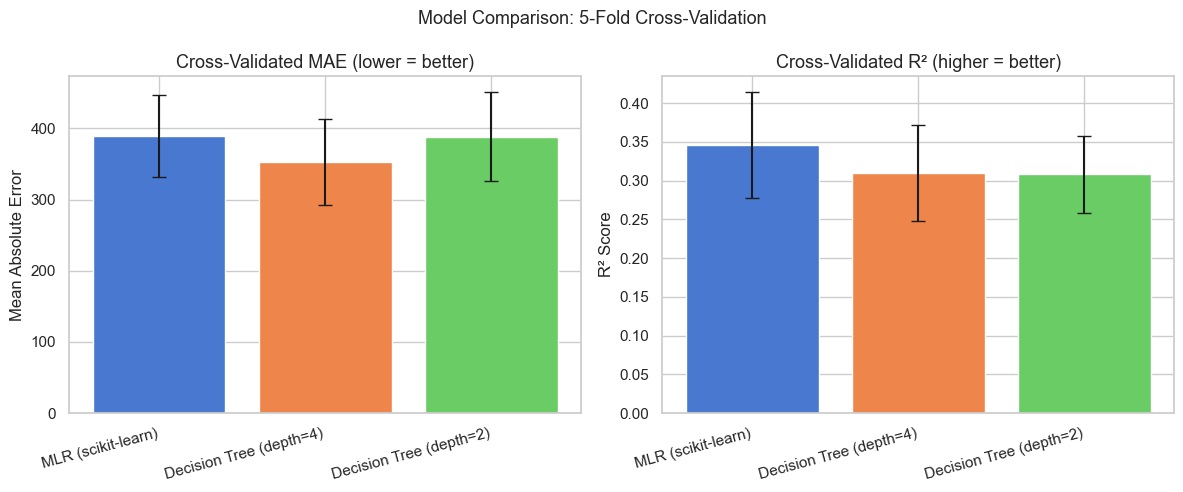

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MAE comparison
axes[0].bar(cv_df.index, cv_df['CV MAE (mean)'],
            yerr=cv_df['CV MAE (std)'], capsize=5,
            color=sns.color_palette('muted', 3))
axes[0].set_title('Cross-Validated MAE (lower = better)')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_xticklabels(cv_df.index, rotation=15, ha='right')

# R² comparison
axes[1].bar(cv_df.index, cv_df['CV R² (mean)'],
            yerr=cv_df['CV R² (std)'], capsize=5,
            color=sns.color_palette('muted', 3))
axes[1].set_title('Cross-Validated R² (higher = better)')
axes[1].set_ylabel('R² Score')
axes[1].set_xticklabels(cv_df.index, rotation=15, ha='right')

plt.suptitle('Model Comparison: 5-Fold Cross-Validation', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Donor Count Analysis — Which Campaigns Attract More Supporters?

The composite score weights value *and* donor count equally. Here we look specifically at donor acquisition per campaign and check whether recurring donors cluster around specific campaigns.

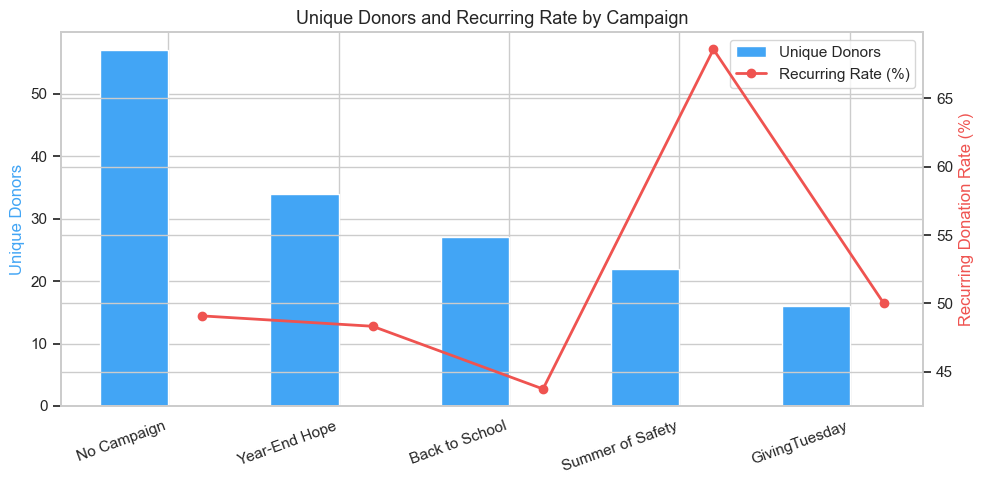

        campaign  unique_donors  recurring_rate  avg_value
     No Campaign             57        0.490909 686.683418
   Year-End Hope             34        0.483333 757.891000
  Back to School             27        0.437500 755.570938
Summer of Safety             22        0.685714 627.498857
   GivingTuesday             16        0.500000 736.426667


In [63]:
# ── Donor retention by campaign ──────────────────────────────────────
donor_campaign = (
    df_model
    .groupby('campaign')
    .agg(
        unique_donors  = ('supporter_id', 'nunique'),
        recurring_rate = ('is_recurring', 'mean'),
        avg_value      = ('estimated_value', 'mean')
    )
    .reset_index()
    .sort_values('unique_donors', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(donor_campaign))
bar_width = 0.4

bars = ax.bar([i - bar_width/2 for i in x],
              donor_campaign['unique_donors'], width=bar_width,
              label='Unique Donors', color='#42A5F5')

ax2 = ax.twinx()
ax2.plot([i + bar_width/2 for i in x],
         donor_campaign['recurring_rate'] * 100,
         marker='o', color='#EF5350', label='Recurring Rate (%)', linewidth=2)

ax.set_xticks(list(x))
ax.set_xticklabels(donor_campaign['campaign'], rotation=20, ha='right')
ax.set_ylabel('Unique Donors', color='#42A5F5')
ax2.set_ylabel('Recurring Donation Rate (%)', color='#EF5350')
ax.set_title('Unique Donors and Recurring Rate by Campaign')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

print(donor_campaign.to_string(index=False))

## 7. Channel Effectiveness Within Campaigns

Campaigns are delivered through channels (Social Media, Events, Direct, Partner Referrals). This section reveals which channel + campaign combinations generate the most value — helping the founders know *how* to run each campaign.

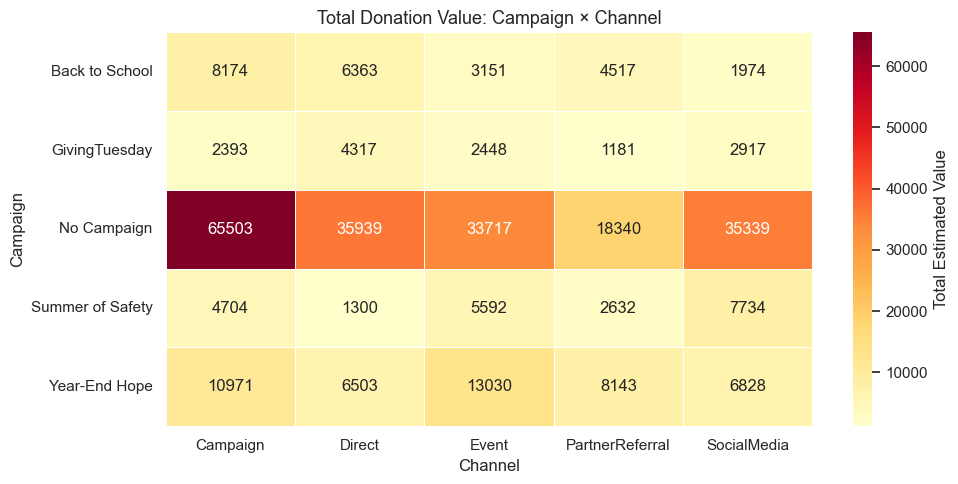

In [64]:
# ── Campaign × Channel heatmap ────────────────────────────────────────
channel_pivot = (
    df_model
    .groupby(['campaign', 'channel_source'])['estimated_value']
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(10, 5))
sns.heatmap(channel_pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Total Estimated Value'})
plt.title('Total Donation Value: Campaign × Channel')
plt.xlabel('Channel')
plt.ylabel('Campaign')
plt.tight_layout()
plt.show()

## 8. Results Summary & Recommendations

This section synthesizes findings from all three methods into actionable insights for the founders.

In [65]:
# ── Final composite leaderboard ────────────────────────────────────────
print('=' * 60)
print('CAMPAIGN EFFECTIVENESS LEADERBOARD')
print('Composite Score = 50% Total Value + 50% Unique Donors')
print('=' * 60)

leaderboard = campaign_summary[['campaign','total_value','donor_count',
                                 'mean_value','composite_score']].copy()
leaderboard = leaderboard.sort_values('composite_score', ascending=False)
leaderboard['rank'] = range(1, len(leaderboard)+1)
leaderboard['verdict'] = leaderboard['composite_score'].apply(
    lambda s: '✅ Moving the needle' if s > 0.6
              else '⚠️  Mixed results' if s > 0.3
              else '🔴 Noise / baseline'
)

print(leaderboard[['rank','campaign','total_value','donor_count',
                    'mean_value','composite_score','verdict']]
      .to_string(index=False))

print()
print('--- MLR Insights ---')
print('Significant campaign effects (p < 0.05):')
sig = campaign_coefs[campaign_coefs['significant']]
if len(sig) > 0:
    for _, row in sig.iterrows():
        direction = 'ABOVE' if row['coef'] > 0 else 'BELOW'
        print(f"  {row['label']}: {row['coef']:+.1f} units {direction} baseline (p={row['pval']:.3f})")
else:
    print('  No campaign reached p < 0.05 — small sample size likely limits significance.')
    print('  Look at effect sizes (coefficients) directionally.')

print()
print('--- Best Model (Cross-Validation) ---')
best_model = cv_df['CV R² (mean)'].idxmax()
print(f'  {best_model} had the highest CV R²: {cv_df.loc[best_model, "CV R² (mean)"]:.3f}')
print(f'  With MAE of {cv_df.loc[best_model, "CV MAE (mean)"]:.1f} estimated value units')

CAMPAIGN EFFECTIVENESS LEADERBOARD
Composite Score = 50% Total Value + 50% Unique Donors
 rank         campaign  total_value  donor_count  mean_value  composite_score             verdict
    1      No Campaign    188837.94           57  686.683418            1.000 ✅ Moving the needle
    2    Year-End Hope     45473.46           34  757.891000            0.311   ⚠️  Mixed results
    3   Back to School     24178.27           27  755.570938            0.165  🔴 Noise / baseline
    4 Summer of Safety     21962.46           22  627.498857            0.098  🔴 Noise / baseline
    5    GivingTuesday     13255.68           16  736.426667            0.000  🔴 Noise / baseline

--- MLR Insights ---
Significant campaign effects (p < 0.05):
  No campaign reached p < 0.05 — small sample size likely limits significance.
  Look at effect sizes (coefficients) directionally.

--- Best Model (Cross-Validation) ---
  MLR (scikit-learn) had the highest CV R²: 0.346
  With MAE of 389.3 estimated value uni

In [66]:
print("""
╔══════════════════════════════════════════════════════════════╗
║          STRATEGIC RECOMMENDATIONS FOR LIGHTHOUSE           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. DOUBLE DOWN on top composite-scoring campaigns.          ║
║     These are moving the needle on both value AND donors.    ║
║                                                              ║
║  2. INVESTIGATE campaigns with high value but low donors     ║
║     — a small number of large donors is fragile. Broaden.    ║
║                                                              ║
║  3. USE THE CHANNEL HEATMAP to focus campaign channels.       ║
║     Some channel+campaign pairs are clearly outperforming.   ║
║                                                              ║
║  4. TRACK RECURRING RATE per campaign — recurring donors      ║
║     are far more valuable long-term than one-time givers.    ║
║                                                              ║
║  5. DATA LIMITATION: With 420 total donations and 4 named    ║
║     campaigns, statistical significance is hard to reach.   ║
║     These patterns are directionally informative but should  ║
║     be re-run as more data accumulates.                      ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║          STRATEGIC RECOMMENDATIONS FOR LIGHTHOUSE           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. DOUBLE DOWN on top composite-scoring campaigns.          ║
║     These are moving the needle on both value AND donors.    ║
║                                                              ║
║  2. INVESTIGATE campaigns with high value but low donors     ║
║     — a small number of large donors is fragile. Broaden.    ║
║                                                              ║
║  3. USE THE CHANNEL HEATMAP to focus campaign channels.       ║
║     Some channel+campaign pairs are clearly outperforming.   ║
║                                                              ║
║  4. TRACK RECURRING RATE per campaign — recurring donors      ║
║     are far more valuable long-term than one-time givers.    ║
║                      

In [67]:
import joblib

# 1. Identify the best model based on the highest Cross-Validated R²
# (This uses the logic already present in your notebook)
best_model_name = cv_df['CV R² (mean)'].idxmax()

# 2. Extract the winning model object from your 'models' dictionary
best_model_object = models[best_model_name]

# 3. Create a safe filename (e.g., "decision_tree_depth=4" -> "decision_tree_depth_4.pkl")
safe_name = best_model_name.replace(' ', '_').replace('(', '').replace(')', '').replace('=', '_').lower()
filename = f"{safe_name}_model.pkl"

# 4. Export ONLY the best model
joblib.dump(best_model_object, filename)

print(f"✅ Successfully exported the best model: '{best_model_name}'")
print(f"📦 Saved as: {filename}")

✅ Successfully exported the best model: 'MLR (scikit-learn)'
📦 Saved as: mlr_scikit-learn_model.pkl
